# Clean and Preprocess Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [4]:
# Load the data
df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape

(395, 33)

In [6]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
# Convert binary categorical columns
binary_map = {"yes": 1, "no": 0}

binary_columns = [
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

for col in binary_columns:
    df[col] = df[col].map(binary_map)

df["sex"] = df["sex"].map({"F": 0, "M": 1})
df["address"] = df["address"].map({"R": 0, "U": 1})
df["famsize"] = df["famsize"].map({"LE3": 0, "GT3": 1})
df["Pstatus"] = df["Pstatus"].map({"A": 0, "T": 1})

print("Simple categorical columns converted.")

Simple categorical columns converted.


In [9]:
# One-hot encode multi-category columns
cleaned_df = pd.get_dummies(
    df,
    columns=["school", "Mjob", "Fjob", "reason", "guardian"],
    drop_first=True
)

for col in cleaned_df.columns:
    if cleaned_df[col].dtype == "bool":
        cleaned_df[col] = cleaned_df[col].astype(int)

print("Cleaned dataset shape:", cleaned_df.shape)
cleaned_df.head()

Cleaned dataset shape: (395, 42)


,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,18,1,1,0,4,4,2,2,0,...,0,0,0,0,1,0,0,0,1,0
1,0,17,1,1,1,1,1,1,2,0,...,0,0,1,0,0,0,0,0,0,0
2,0,15,1,0,1,1,1,1,2,3,...,0,0,1,0,0,0,1,0,1,0
3,0,15,1,1,1,4,2,1,3,0,...,0,0,0,1,0,1,0,0,1,0
4,0,16,1,1,1,3,3,1,2,0,...,0,0,1,0,0,1,0,0,0,0


# Exploratory Data Analysis


In [10]:
# 1. Basic statistics
numeric_cols = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
                "famrel", "freetime", "goout", "Dalc", "Walc", "health",
                "absences", "G1", "G2", "G3"]

print("\nBasic statistics:")
print(cleaned_df[numeric_cols].describe())


Basic statistics:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std     

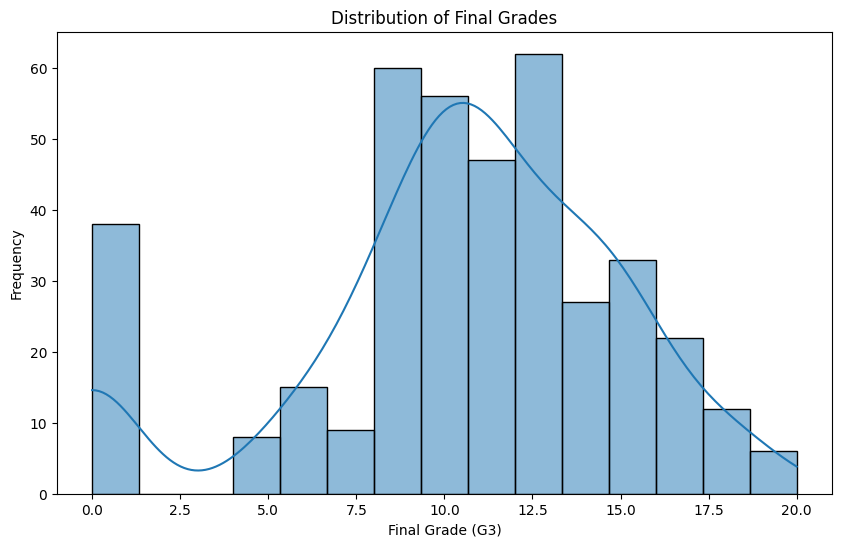

In [11]:
# 2. Histogram of final grade
plt.figure(figsize=(10, 6))
sns.histplot(data=cleaned_df, x="G3", bins=15, kde=True)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.show()

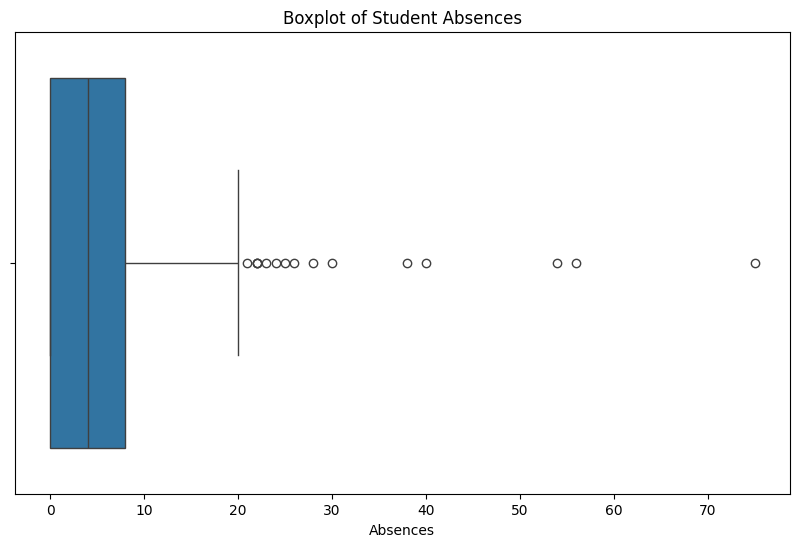

In [12]:
# 3. Boxplot of absences
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_df["absences"], orient="h")
plt.title("Boxplot of Student Absences")
plt.xlabel("Absences")
plt.show()

In [13]:
# 4. Average final grade by study time
avg_grade = cleaned_df.groupby("studytime")["G3"].mean().sort_values()
print(avg_grade)

studytime
1    10.047619
2    10.171717
4    11.259259
3    11.400000
Name: G3, dtype: float64


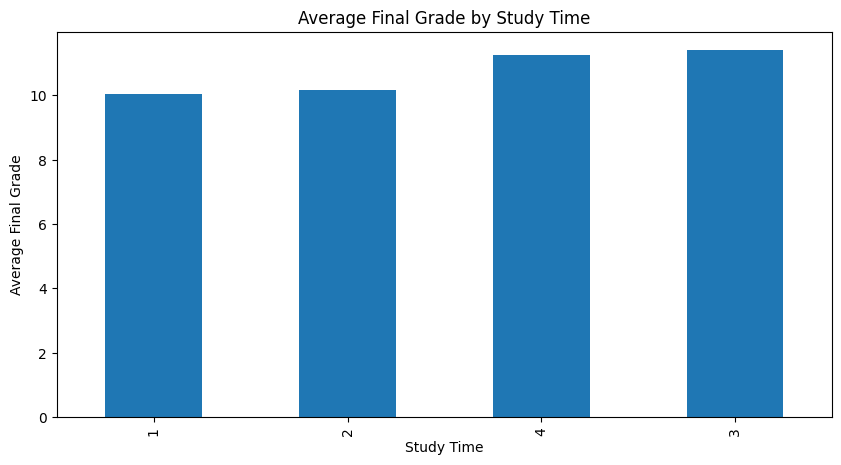

In [14]:
avg_grade.plot(kind="bar", figsize=(10, 5))
plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")
plt.show()

# Principal Component Analysis (PCA)

In [15]:
# 5. Principal Component Analysis (PCA):
# Select relevant numeric variables for PCA

student_cols = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
    'absences', 'G1', 'G2', 'G3'
]

In [16]:
# Create a subset with only student numeric data
student_df = cleaned_df[student_cols]
student_df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10


In [17]:
# Standardize the data (important for PCA)
scaler = StandardScaler()
student_scaled = scaler.fit_transform(student_df)

In [18]:
# Perform PCA
pca = PCA()
principal_components = pca.fit_transform(student_scaled)

In [19]:
# Eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

print("Eigenvalues (Explained Variance):")
print(eigenvalues)
print("\n")

# Calculate total variation
total_variation = sum(eigenvalues)
print(f"Total Variation: {total_variation:.4f}")

Eigenvalues (Explained Variance):
[3.40422332 2.09764503 1.56165835 1.28293743 1.17259809 1.01530891
 0.93288936 0.90077492 0.77188583 0.71885914 0.63569    0.62093457
 0.365001   0.2957795  0.18414921 0.0802745 ]


Total Variation: 16.0406


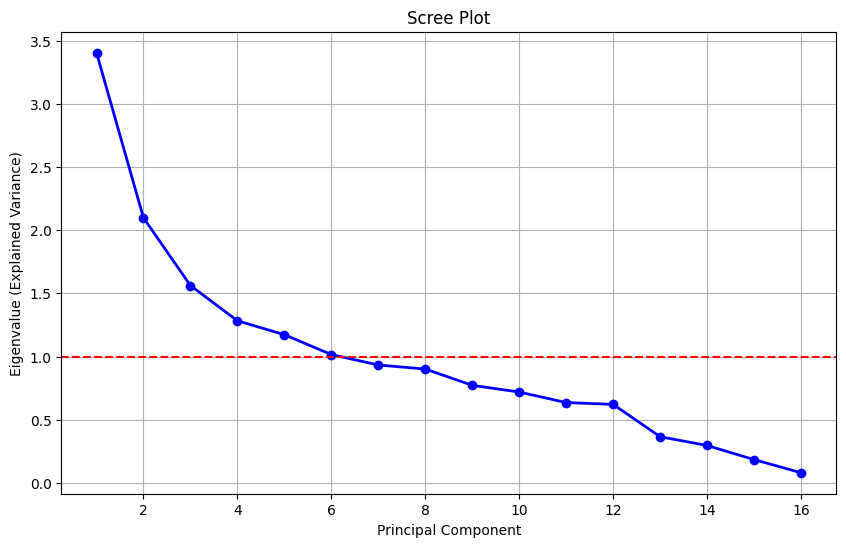

In [20]:
# Scree plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.axhline(y=1, color='r', linestyle='--')  # Kaiser criterion line
plt.grid()
plt.show()

In [21]:
# Calculate proportion of variation for each component
proportions = eigenvalues / total_variation

print("\nProportion of Total Variation for Each Principal Component:")
for i, prop in enumerate(proportions):
    print(f"PC{i+1}: {prop:.4f} ({prop*100:.2f}%)")


Proportion of Total Variation for Each Principal Component:
PC1: 0.2122 (21.22%)
PC2: 0.1308 (13.08%)
PC3: 0.0974 (9.74%)
PC4: 0.0800 (8.00%)
PC5: 0.0731 (7.31%)
PC6: 0.0633 (6.33%)
PC7: 0.0582 (5.82%)
PC8: 0.0562 (5.62%)
PC9: 0.0481 (4.81%)
PC10: 0.0448 (4.48%)
PC11: 0.0396 (3.96%)
PC12: 0.0387 (3.87%)
PC13: 0.0228 (2.28%)
PC14: 0.0184 (1.84%)
PC15: 0.0115 (1.15%)
PC16: 0.0050 (0.50%)


In [22]:
# Cumulative proportion
cumulative_prop = proportions.cumsum()

print("\nCumulative Proportion of Total Variation:")
for i, cum_prop in enumerate(cumulative_prop):
    print(f"PC1 to PC{i+1}: {cum_prop:.4f} ({cum_prop*100:.2f}%)")


Cumulative Proportion of Total Variation:
PC1 to PC1: 0.2122 (21.22%)
PC1 to PC2: 0.3430 (34.30%)
PC1 to PC3: 0.4404 (44.04%)
PC1 to PC4: 0.5203 (52.03%)
PC1 to PC5: 0.5934 (59.34%)
PC1 to PC6: 0.6567 (65.67%)
PC1 to PC7: 0.7149 (71.49%)
PC1 to PC8: 0.7710 (77.10%)
PC1 to PC9: 0.8192 (81.92%)
PC1 to PC10: 0.8640 (86.40%)
PC1 to PC11: 0.9036 (90.36%)
PC1 to PC12: 0.9423 (94.23%)
PC1 to PC13: 0.9651 (96.51%)
PC1 to PC14: 0.9835 (98.35%)
PC1 to PC15: 0.9950 (99.50%)
PC1 to PC16: 1.0000 (100.00%)


In [23]:
# Eigenvectors (loadings)
eigenvectors = pca.components_

print("\nEigenvectors (Principal Components Loadings):")

for i, component in enumerate(eigenvectors):
    print(f"\nPrincipal Component {i+1}:")
    print(pd.Series(component, index=student_cols))


Eigenvectors (Principal Components Loadings):

Principal Component 1:
age          -0.165593
Medu          0.230058
Fedu          0.207601
traveltime   -0.145487
studytime     0.155876
failures     -0.317766
famrel        0.019469
freetime     -0.064175
goout        -0.165888
Dalc         -0.167198
Walc         -0.191400
health       -0.070390
absences     -0.037371
G1            0.451066
G2            0.467762
G3            0.452654
dtype: float64

Principal Component 2:
age           0.067118
Medu          0.212822
Fedu          0.197155
traveltime    0.036313
studytime    -0.216797
failures      0.003338
famrel       -0.025530
freetime      0.290236
goout         0.374682
Dalc          0.500410
Walc          0.518704
health        0.058478
absences      0.159012
G1            0.150334
G2            0.170128
G3            0.194972
dtype: float64

Principal Component 3:
age          -0.251969
Medu          0.536136
Fedu          0.564329
traveltime   -0.242593
studytime     0.006640


In [24]:
# School-wise data balance
print(cleaned_df['school_MS'].value_counts())

school_MS
0    349
1     46
Name: count, dtype: int64


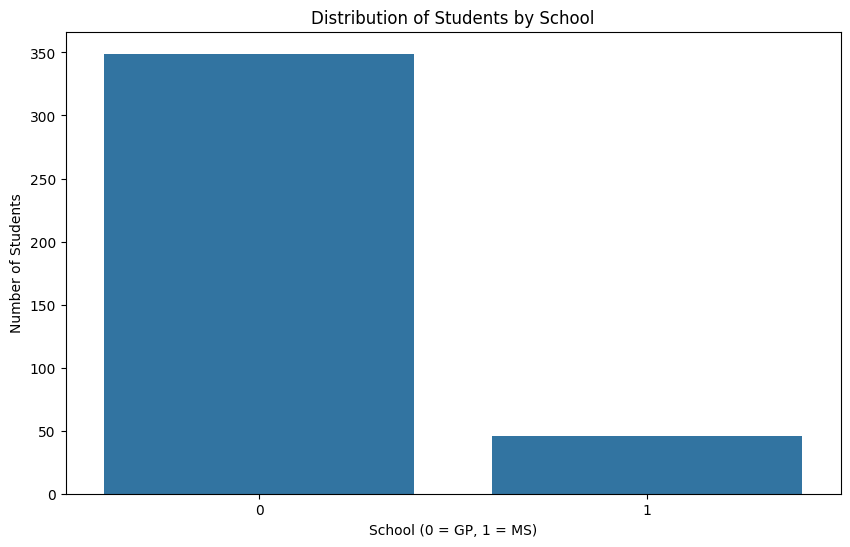

In [25]:
# Count plot for school distribution
plt.figure(figsize=(10,6))
sns.countplot(x='school_MS', data=cleaned_df)
plt.xlabel("School (0 = GP, 1 = MS)")
plt.ylabel("Number of Students")
plt.title("Distribution of Students by School")
plt.show()

                  G1         G2         G3
studytime                                 
1          10.438095  10.276190  10.047619
2          10.651515  10.505051  10.171717
3          12.046154  11.507692  11.400000
4          11.888889  12.037037  11.259259


<Figure size 1200x600 with 0 Axes>

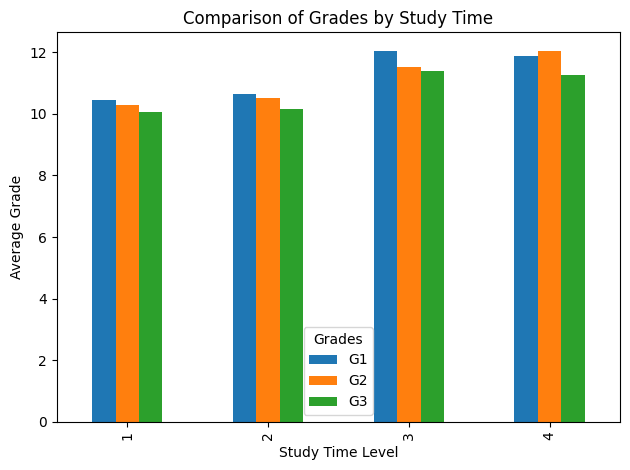

In [26]:
data = cleaned_df.copy()

study_stats = data.groupby('studytime')[['G1','G2','G3']].mean()
print(study_stats)

plt.figure(figsize=(12,6))
study_stats.plot(kind='bar')
plt.title("Comparison of Grades by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average Grade")
plt.legend(title="Grades")
plt.tight_layout()
plt.show()

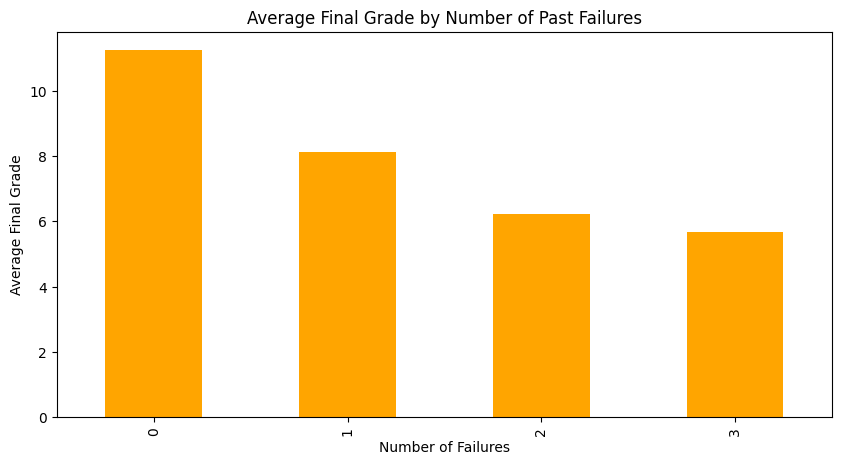

In [27]:
fail_stats = data.groupby('failures')['G3'].mean()

plt.figure(figsize=(10,5))
fail_stats.plot(kind='bar', color='orange')
plt.title("Average Final Grade by Number of Past Failures")
plt.xlabel("Number of Failures")
plt.ylabel("Average Final Grade")
plt.show()

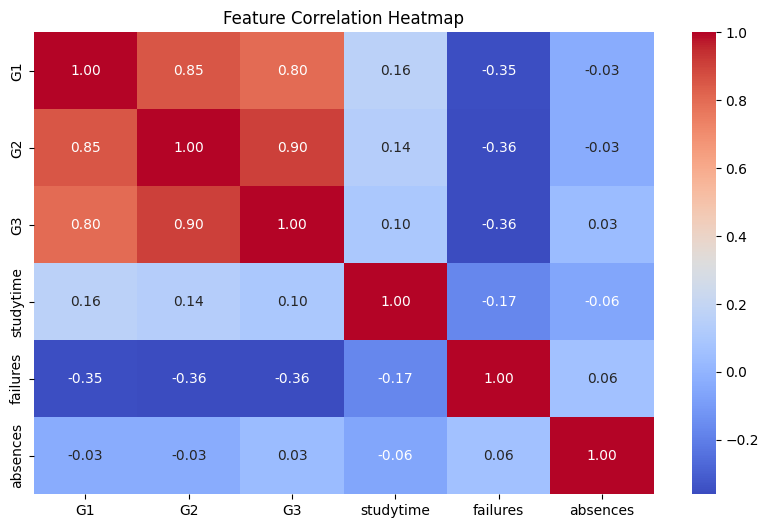

In [28]:
# Correlation heatmap
corr_cols = ["G1", "G2", "G3", "studytime", "failures", "absences"]
plt.figure(figsize=(10, 6))
sns.heatmap(cleaned_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

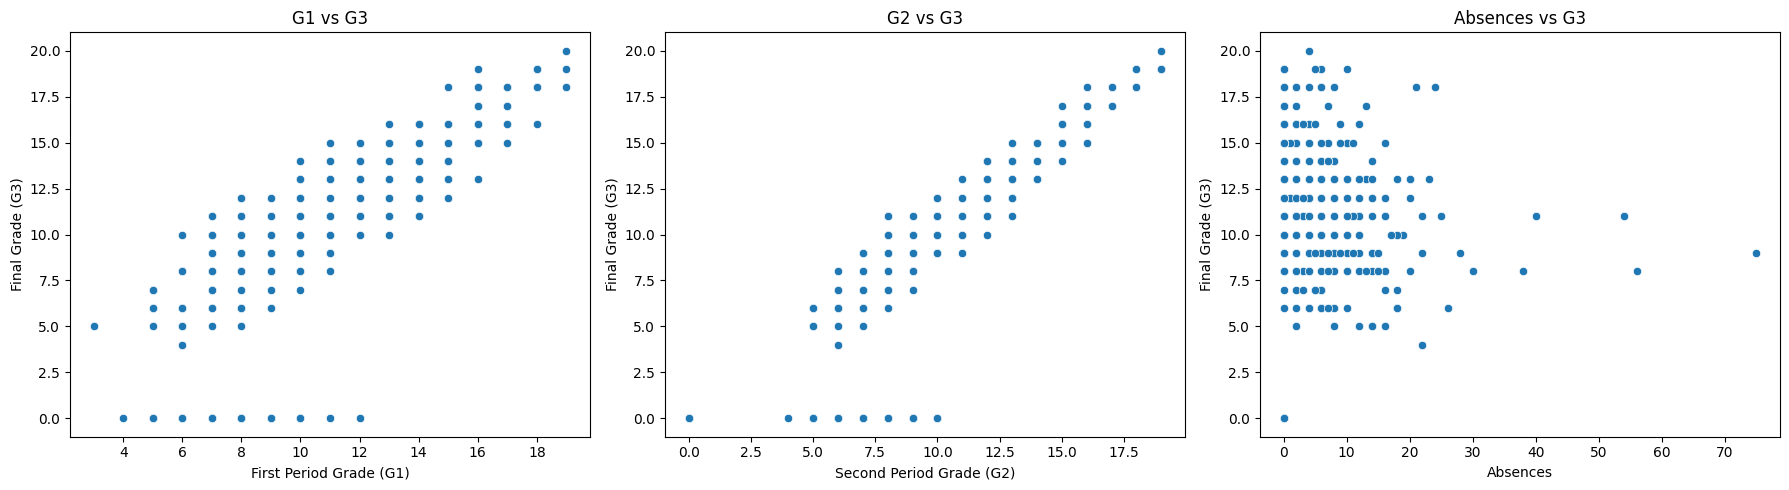

In [29]:
# Set up the figure
plt.figure(figsize=(18, 5))

# Plot 1: G1 vs G3
plt.subplot(1, 3, 1)
sns.scatterplot(x="G1", y="G3", data=cleaned_df)
plt.title("G1 vs G3")
plt.xlabel("First Period Grade (G1)")
plt.ylabel("Final Grade (G3)")

# Plot 2: G2 vs G3
plt.subplot(1, 3, 2)
sns.scatterplot(x="G2", y="G3", data=cleaned_df)
plt.title("G2 vs G3")
plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

# Plot 3: Absences vs G3
plt.subplot(1, 3, 3)
sns.scatterplot(x="absences", y="G3", data=cleaned_df)
plt.title("Absences vs G3")
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

# ML / AI Methods

In [30]:
# Select features and target
X = cleaned_df[["studytime", "failures", "absences", "schoolsup",
                "famsup", "higher", "internet", "G1", "G2"]]
y = cleaned_df["G3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=88
)

Linear Regression

In [31]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [32]:
print("\nLinear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Performance:
MAE: 1.19117211787797
MSE: 3.3251279737959267
R2 Score: 0.8556105349176844


Random Forest Regressor

In [33]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=88)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [34]:
print("\nRandom Forest Performance:")

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)


Random Forest Performance:
MAE: 0.9310074029611844
MSE: 2.2240278919925114
R2 Score: 0.9034244094712677



Feature Importance:
G2           0.780183
absences     0.124143
studytime    0.028493
G1           0.026518
failures     0.017630
famsup       0.010210
schoolsup    0.006497
internet     0.005229
higher       0.001098
dtype: float64


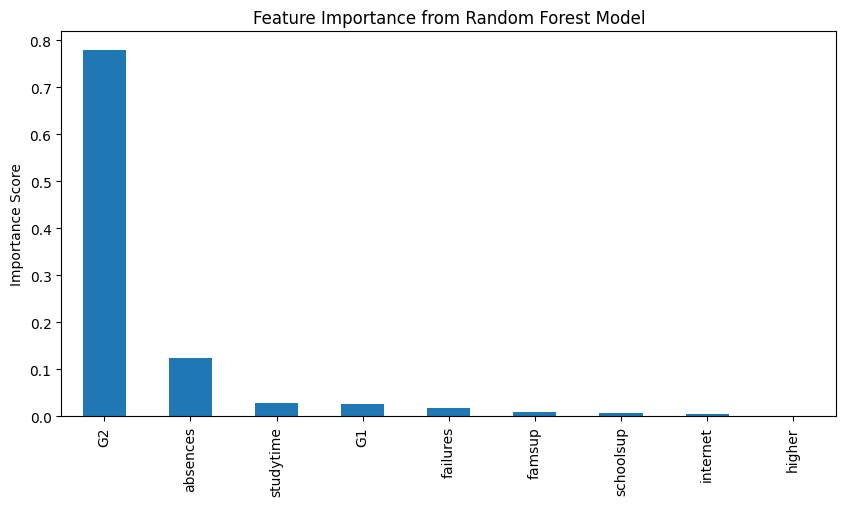

In [35]:
# Feature Importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance from Random Forest Model")
plt.ylabel("Importance Score")
plt.show()

Neural Network Model - Student Performance Prediction

In [36]:
# Neural Network Model
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)   # Output layer for regression
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = nn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 66.9488 - mae: 7.2169 - val_loss: 14.4824 - val_mae: 3.4656
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.3629 - mae: 2.6243 - val_loss: 5.8353 - val_mae: 1.5126
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.0593 - mae: 2.3366 - val_loss: 5.7160 - val_mae: 1.8131
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7458 - mae: 2.0702 - val_loss: 4.4744 - val_mae: 1.3349
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8876 - mae: 2.0350 - val_loss: 4.6313 - val_mae: 1.5888
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6570 - mae: 1.8946 - val_loss: 4.2013 - val_mae: 1.4713
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9679 - mae: 1.9770 - val_loss: 4.7947 - val_mae: 1.7265
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4602 - mae: 1.8661 - val_loss: 4.2076 - val_mae: 1.5472
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4706 - mae

Evaluate the Neural Network

In [37]:
# Predict on test data
nn_pred = nn_model.predict(X_test).flatten()

# Evaluation metrics
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_mse = mean_squared_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

print("\nNeural Network Performance:")
print("MAE:", nn_mae)
print("MSE:", nn_mse)
print("R2 Score:", nn_r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Neural Network Performance:
MAE: 1.7802464962005615
MSE: 4.705598831176758
R2 Score: 0.7956653833389282


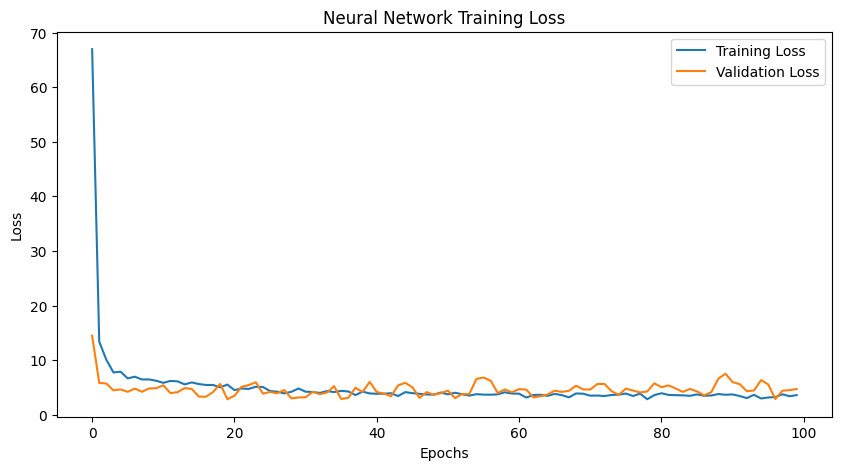

In [38]:
#Training Graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Neural Network Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()